# The Iris Dataset — What Is Actually Inside It

> 📘 **Instructor Curriculum** — M02 Data Visualization (Seaborn)

Before plotting a dataset, you should know what its columns mean. This notebook
opens up `iris` column by column, so that every later Seaborn chart is a chart
you can read.

Related: [`test.ipynb`](./test.ipynb) — the Seaborn plot-type practice that uses this dataset.

## 1. What is it?

The iris dataset is **150 flowers**. Each flower has **4 measurements** taken with
a ruler, plus the **name of its species**.

There are 3 species — *setosa*, *versicolor*, *virginica* — and exactly 50 flowers
of each.

The measurements were collected in 1935 by the botanist Edgar Anderson. The
statistician Ronald Fisher used them in a 1936 paper, and the data has been the
standard teaching example ever since.

## 2. Why does everyone use it?

- It is **small**. 150 rows loads instantly and prints on one screen.
- It is **clean**. No missing values, no weird encodings, no date parsing.
- It is **balanced**. 50 of each species, so accuracy numbers are honest.
- The answer is **visible**. You can see the species separate in a scatter plot.
  You do not need a model to believe the result.

**Engineering view:** iris is a seed-data fixture. It is the `data.sql` you keep
in test resources. You use it to prove the *pipeline* runs — the loader, the
plot call, the training loop. You never use it to prove the *model* is good.
Any algorithm scores well on iris. That says nothing about your real problem.

In [1]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# One consistent look and one consistent colour per species for the whole notebook.
sns.set_theme(style="whitegrid", context="notebook")

SPECIES_ORDER = ["setosa", "versicolor", "virginica"]
SPECIES_COLORS = {
    "setosa":     "#0173B2",  # blue
    "versicolor": "#DE8F05",  # orange
    "virginica":  "#029E73",  # green
}

FEATURES = ["sepal_length", "sepal_width", "petal_length", "petal_width"]

iris = sns.load_dataset("iris")
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


## 3. The five columns

`sns.load_dataset("iris")` returns a normal Pandas DataFrame. Five columns:

| Column | Meaning | Type | Unit | Role |
|---|---|---|---|---|
| `sepal_length` | length of the outer leaf | `float64` | cm | feature |
| `sepal_width`  | width of the outer leaf  | `float64` | cm | feature |
| `petal_length` | length of the inner leaf | `float64` | cm | feature |
| `petal_width`  | width of the inner leaf  | `float64` | cm | feature |
| `species`      | which flower it is       | `str`     | —  | **label** |

Two words you will see constantly:

- A **feature** is an input. Something you measure. Usually written `X`.
- A **label** (or *target*) is the answer you want to predict. Usually written `y`.

So iris is 4 features and 1 label. In plotting terms, the 4 features go on your
axes, and the label goes into `hue`.

## 4. Sepal and petal — what are they?

This trips up most people, because the words are botanical, not technical.

- A **petal** is the coloured inner leaf. This is the part you think of as "the flower".
- A **sepal** is the outer leaf. It wrapped and protected the flower while it was
  still a closed bud. On an iris it is large and looks like a second set of petals.

Every flower has both. The dataset measures the **length** and the **width** of
one of each — that is where the 4 numbers come from.

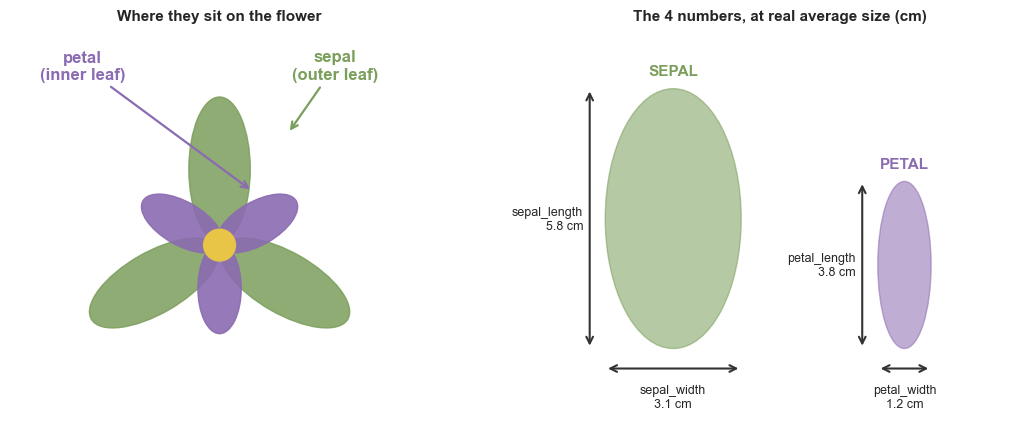

In [2]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.6))
for ax in (ax1, ax2):
    ax.set_aspect("equal"); ax.axis("off"); ax.grid(False)

SEPAL_C, PETAL_C = "#7A9E5B", "#8B6BB1"

# --- Left: where the parts sit on the flower ---
ax1.set_title("Where they sit on the flower", fontsize=11, weight="bold")
from matplotlib.patches import Ellipse
for angle in (90, 210, 330):            # 3 outer sepals, drooping
    r = np.deg2rad(angle)
    ax1.add_patch(Ellipse((1.05*np.cos(r), 1.05*np.sin(r)), 0.85, 2.0,
                          angle=angle - 90, color=SEPAL_C, alpha=.85))
for angle in (30, 150, 270):            # 3 inner petals, upright
    r = np.deg2rad(angle)
    ax1.add_patch(Ellipse((0.60*np.cos(r), 0.60*np.sin(r)), 0.60, 1.25,
                          angle=angle - 90, color=PETAL_C, alpha=.9))
ax1.add_patch(plt.Circle((0, 0), 0.22, color="#E8C547"))
ax1.annotate("sepal\n(outer leaf)", xy=(0.95, 1.55), xytext=(1.6, 2.3),
             color=SEPAL_C, weight="bold", ha="center",
             arrowprops=dict(arrowstyle="->", color=SEPAL_C, lw=1.6))
ax1.annotate("petal\n(inner leaf)", xy=(0.45, 0.75), xytext=(-1.9, 2.3),
             color=PETAL_C, weight="bold", ha="center",
             arrowprops=dict(arrowstyle="->", color=PETAL_C, lw=1.6))
ax1.set_xlim(-2.9, 2.9); ax1.set_ylim(-2.6, 3.0)

# --- Right: the 4 measurements, drawn to the real average size ---
ax2.set_title("The 4 numbers, at real average size (cm)", fontsize=11, weight="bold")
m = iris[["sepal_length", "sepal_width", "petal_length", "petal_width"]].mean()

def draw(cx, w, h, colour, name, wkey, hkey):
    ax2.add_patch(Ellipse((cx, h/2), w, h, color=colour, alpha=.55))
    ax2.annotate("", xy=(cx - w/2 - .35, 0), xytext=(cx - w/2 - .35, h),
                 arrowprops=dict(arrowstyle="<->", color="#333", lw=1.5))
    ax2.text(cx - w/2 - .5, h/2, f"{hkey}\n{m[hkey]:.1f} cm", ha="right",
             va="center", fontsize=9)
    ax2.annotate("", xy=(cx - w/2, -.45), xytext=(cx + w/2, -.45),
                 arrowprops=dict(arrowstyle="<->", color="#333", lw=1.5))
    ax2.text(cx, -.8, f"{wkey}\n{m[wkey]:.1f} cm", ha="center", va="top", fontsize=9)
    ax2.text(cx, h + .3, name, ha="center", fontsize=11, weight="bold", color=colour)

draw(0.0, m["sepal_width"], m["sepal_length"], SEPAL_C, "SEPAL", "sepal_width", "sepal_length")
draw(5.2, m["petal_width"], m["petal_length"], PETAL_C, "PETAL", "petal_width", "petal_length")
ax2.set_xlim(-2.6, 7.4); ax2.set_ylim(-1.9, 7.2)

plt.tight_layout(); plt.show()

Notice on the right: the **average sepal is bigger than the average petal**, and
the petal is the narrower of the two. Keep that in mind — the petal columns turn
out to be the important ones.

## 5. The whole dataset in one picture

Here is the structure you just described, drawn out. Read it top to bottom:

**Iris → 3 species → every flower carries the same 4 measurements.**

Each flower below is drawn at its species' **true average size**, straight from the
numbers in the dataset. The three are to scale against each other, so the size
differences you see are real.

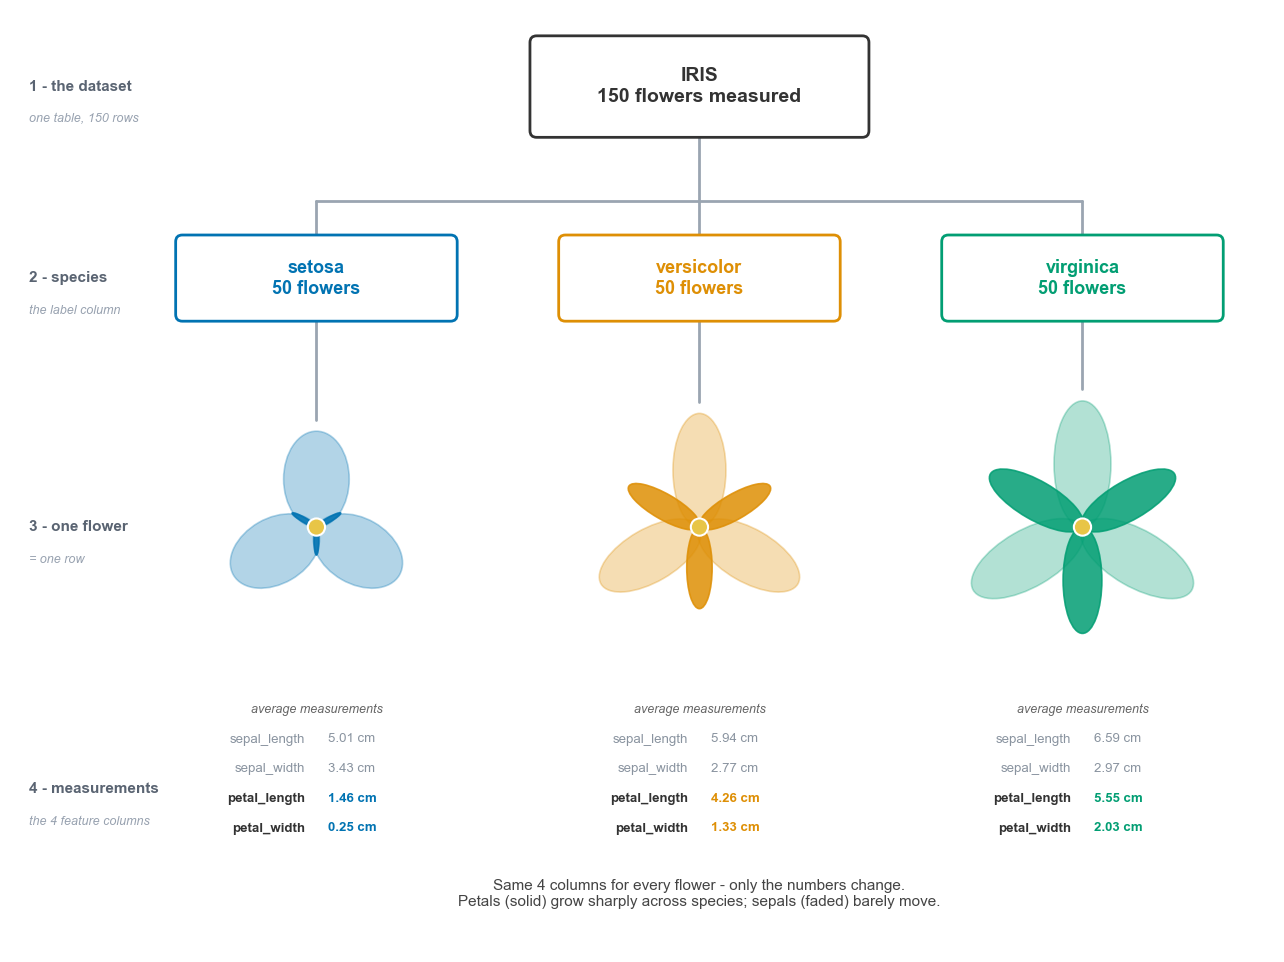

In [3]:
from matplotlib.patches import Ellipse, FancyBboxPatch

means = iris.groupby("species")[FEATURES].mean()

def draw_flower(ax, cx, cy, sl, sw, pl, pw, colour):
    """One schematic iris: 3 outer sepals + 3 inner petals, drawn to real cm."""
    for a in (90, 210, 330):                                    # sepals (outer, faded)
        r = np.deg2rad(a)
        ax.add_patch(Ellipse((cx + (sl/2)*np.cos(r), cy + (sl/2)*np.sin(r)),
                             sw, sl, angle=a-90, facecolor=colour, alpha=.30,
                             edgecolor=colour, lw=1.2))
    for a in (30, 150, 270):                                    # petals (inner, solid)
        r = np.deg2rad(a)
        ax.add_patch(Ellipse((cx + (pl/2)*np.cos(r), cy + (pl/2)*np.sin(r)),
                             pw, pl, angle=a-90, facecolor=colour, alpha=.85,
                             edgecolor=colour, lw=1.2))
    ax.add_patch(plt.Circle((cx, cy), .45, facecolor="#E8C547", edgecolor="white", lw=1.5))

def node(ax, cx, cy, text, colour, w, h, fs):
    ax.add_patch(FancyBboxPatch((cx-w/2, cy-h/2), w, h, boxstyle="round,pad=0.35",
                                linewidth=2, edgecolor=colour, facecolor="white", zorder=3))
    ax.text(cx, cy, text, ha="center", va="center", fontsize=fs,
            weight="bold", color=colour, zorder=4)

fig, ax = plt.subplots(figsize=(13, 10))
ax.set_aspect("equal"); ax.axis("off"); ax.grid(False)

XS = [0, 20, 40]
TOP_Y, BUS_Y, SP_Y, FLOWER_Y = 40, 34, 30, 17
TABLE_Y = FLOWER_Y - means.sepal_length.max() - 2.6      # one shared baseline
LINE = "#9AA5B1"

# the flow, named down the left edge
for y, step, note in [(TOP_Y, "1 - the dataset", "one table, 150 rows"),
                      (SP_Y, "2 - species", "the label column"),
                      (FLOWER_Y, "3 - one flower", "= one row"),
                      (TABLE_Y - 4.5, "4 - measurements", "the 4 feature columns")]:
    ax.text(-15, y, step, ha="left", va="center", fontsize=11, weight="bold", color="#5A6472")
    ax.text(-15, y - 1.7, note, ha="left", va="center", fontsize=9, style="italic", color="#98A2B0")

# level 1: the dataset
node(ax, 20, TOP_Y, "IRIS\n150 flowers measured", "#333", 17, 4.6, 14)
ax.plot([20, 20], [TOP_Y-2.3, BUS_Y], color=LINE, lw=2, zorder=1)
ax.plot([XS[0], XS[2]], [BUS_Y, BUS_Y], color=LINE, lw=2, zorder=1)
for x in XS:
    ax.plot([x, x], [BUS_Y, SP_Y+1.9], color=LINE, lw=2, zorder=1)

# levels 2-4: species -> flower at true average size -> its 4 numbers
for x, sp in zip(XS, SPECIES_ORDER):
    c, m = SPECIES_COLORS[sp], means.loc[sp]
    node(ax, x, SP_Y, f"{sp}\n50 flowers", c, 14, 3.8, 13)
    ax.plot([x, x], [SP_Y-1.9, FLOWER_Y+m.sepal_length+.6], color=LINE, lw=2, zorder=1)
    draw_flower(ax, x, FLOWER_Y, m.sepal_length, m.sepal_width, m.petal_length, m.petal_width, c)

    ax.text(x, TABLE_Y, "average measurements", ha="center", va="top",
            fontsize=9, style="italic", color="#666")
    for i, k in enumerate(FEATURES):
        yy, strong = TABLE_Y - 1.9 - i*1.55, k.startswith("petal")
        ax.text(x-.6, yy, k, ha="right", va="center", fontsize=9.5,
                color="#333" if strong else "#8A94A0", weight="bold" if strong else "normal")
        ax.text(x+.6, yy, f"{m[k]:.2f} cm", ha="left", va="center", fontsize=9.5,
                color=c if strong else "#8A94A0", weight="bold" if strong else "normal")

ax.text(20, TABLE_Y - 9.2,
        "Same 4 columns for every flower - only the numbers change.\n"
        "Petals (solid) grow sharply across species; sepals (faded) barely move.",
        ha="center", va="top", fontsize=11, color="#444")
ax.set_xlim(-16, 50); ax.set_ylim(TABLE_Y - 13, 44)
plt.tight_layout(); plt.show()

**Reading the result**

- Every flower, in all three species, has **exactly the same 4 columns**. The
  structure never changes — only the values do. That is what makes this a table.
- Walk left to right and watch the **solid petals grow**: 1.46 → 4.26 → 5.55 cm.
  Setosa's petals are so small they nearly vanish behind the yellow centre.
- Now watch the **faded sepals**: 5.01 → 5.94 → 6.59 cm. They grow too, but gently —
  and `sepal_width` actually dips before rising (3.43 → 2.77 → 2.97).

That contrast is the entire dataset in one image. It is the same finding the charts
later in this notebook arrive at numerically.

**Mapping the diagram to the table:** level 3 — one flower — is **one row** of the
DataFrame. Level 4 is its 4 numeric columns, the features (`X`). Level 2 is the
`species` column, the label (`y`). Level 1 is the whole 150-row table.

## 6. Shape, types, and data quality

The first three things to check on any new dataset: how big is it, what types are
the columns, and what is missing.

In [4]:
print("rows, columns :", iris.shape)
print("missing values:", iris.isnull().sum().sum())
print("duplicate rows:", iris.duplicated().sum())
print()
iris.info()

rows, columns : (150, 5)
missing values: 0
duplicate rows: 1

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


**Reading the result**

- **150 rows, 5 columns.** Tiny. Everything fits in memory with room to spare.
- **0 missing values.** This is why iris is a teaching set and not a realistic one.
  Real datasets are mostly cleaning work. Here there is none.
- **1 duplicate row.** Two flowers happened to measure identically. It is a genuine
  reading, not a data error, so it is normally left alone.
- **4 float columns + 1 text column.** That split matters: Seaborn treats numeric
  and text columns differently. Numbers go on axes; text goes into `hue`.

In [5]:
iris[iris.duplicated(keep=False)]   # the two identical flowers

,sepal_length,sepal_width,petal_length,petal_width,species
101,5.8,2.7,5.1,1.9,virginica
142,5.8,2.7,5.1,1.9,virginica


## 7. Class balance

Before trusting any accuracy number, count the labels.

species
setosa        50
versicolor    50
virginica     50


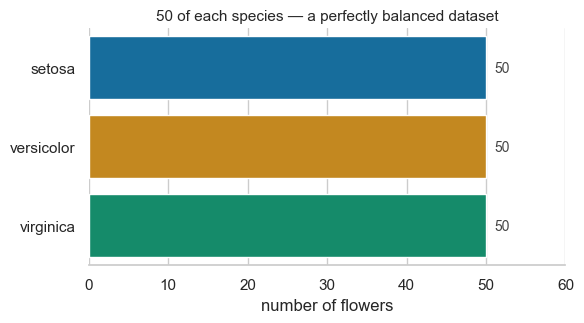

In [6]:
counts = iris["species"].value_counts()[SPECIES_ORDER]
print(counts.to_string())

fig, ax = plt.subplots(figsize=(6, 3.4))
sns.countplot(data=iris, y="species", order=SPECIES_ORDER,
              hue="species", hue_order=SPECIES_ORDER,
              palette=SPECIES_COLORS, legend=False, ax=ax)
for i, v in enumerate(counts):
    ax.text(v + 1, i, str(v), va="center", fontsize=10, color="#444")
ax.set_xlim(0, 60); ax.set_xlabel("number of flowers"); ax.set_ylabel("")
ax.set_title("50 of each species — a perfectly balanced dataset", fontsize=11)
sns.despine(left=True); plt.tight_layout(); plt.show()

**Why this matters.** Suppose the split were 140 / 5 / 5 instead. A model that
always answered *"setosa"* would score 93% accuracy while being useless. That is
the **imbalanced class problem**, and it is one of the most common ways an ML
result lies to you.

Iris has none of it. 50 / 50 / 50 means a random guess scores 33%, so anything
above that is real signal. This is another reason it is a good first dataset —
one fewer thing to get wrong.

## 8. What range are the numbers in?

`describe()` gives the five-number summary of every numeric column.

In [7]:
iris.describe().round(2)

,sepal_length,sepal_width,petal_length,petal_width
count,150.00,150.00,150.00,150.00
mean,5.84,3.06,3.76,1.20
std,0.83,0.44,1.77,0.76
min,4.30,2.00,1.00,0.10
25%,5.10,2.80,1.60,0.30
50%,5.80,3.00,4.35,1.30
75%,6.40,3.30,5.10,1.80
max,7.90,4.40,6.90,2.50


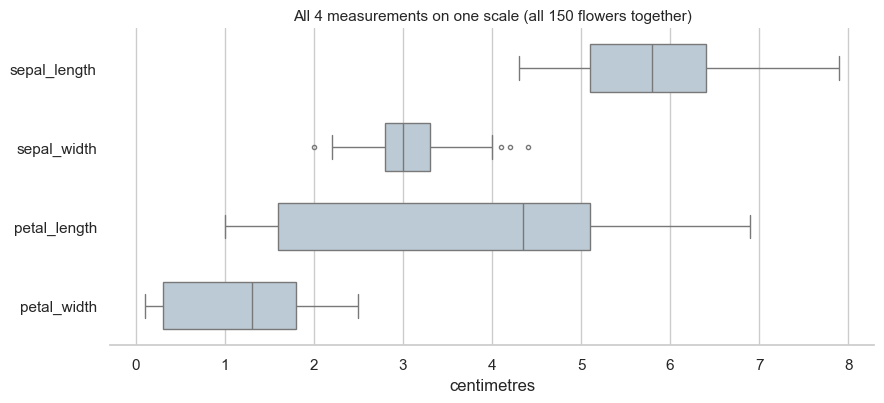

In [8]:
long = iris.melt(id_vars="species", var_name="measurement", value_name="cm")

fig, ax = plt.subplots(figsize=(9, 4.2))
sns.boxplot(data=long, x="cm", y="measurement", color="#B8CBD9",
            width=.6, fliersize=3, ax=ax)
ax.set_xlabel("centimetres"); ax.set_ylabel("")
ax.set_title("All 4 measurements on one scale (all 150 flowers together)", fontsize=11)
sns.despine(left=True); plt.tight_layout(); plt.show()

**Reading the result**

- Everything sits between **0.1 cm and 7.9 cm**. All four columns are already on a
  similar scale, so this dataset does not need feature scaling. Most real datasets do.
- `sepal_width` is the tightest column (2.0–4.4, std 0.44).
- `petal_length` is the widest spread (1.0–6.9, std 1.77) — and that wide spread is
  a hint. A column that varies a lot is a column that might separate the groups.

Note that this chart mixes all three species together. That is exactly why the
petal boxes look so stretched — we are seeing three groups stacked into one box.
Splitting by species is the next step.

## 9. The core table — averages per species

This one table is the heart of the dataset.

In [9]:
means = iris.groupby("species")[
    ["sepal_length", "sepal_width", "petal_length", "petal_width"]
].mean().round(2).loc[SPECIES_ORDER]
means

,sepal_length,sepal_width,petal_length,petal_width
species,,,,
setosa,5.01,3.43,1.46,0.25
versicolor,5.94,2.77,4.26,1.33
virginica,6.59,2.97,5.55,2.03


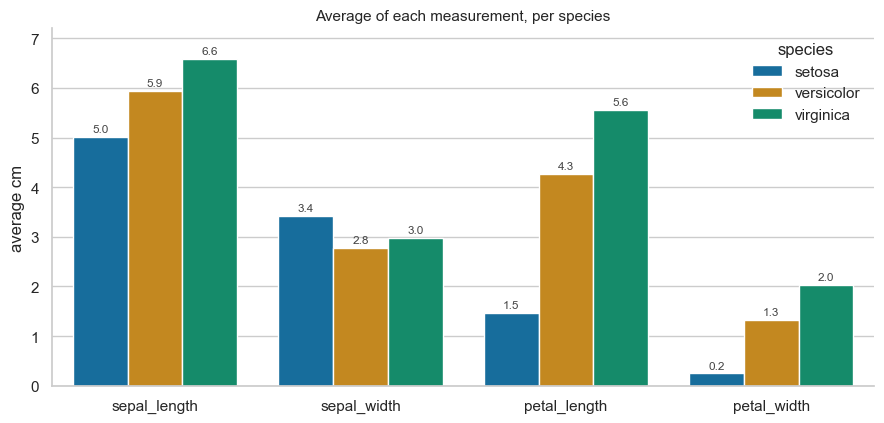

In [10]:
fig, ax = plt.subplots(figsize=(9, 4.4))
sns.barplot(data=long, x="measurement", y="cm",
            hue="species", hue_order=SPECIES_ORDER,
            palette=SPECIES_COLORS, errorbar=None, ax=ax)
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f", fontsize=8.5, padding=2, color="#444")
ax.set_ylim(0, 7.2); ax.set_xlabel(""); ax.set_ylabel("average cm")
ax.set_title("Average of each measurement, per species", fontsize=11)
ax.legend(title="species", frameon=False)
sns.despine(); plt.tight_layout(); plt.show()

**Reading the result** — look at the size of the gaps, not the heights.

- **`sepal_width`**: 3.43 / 2.77 / 2.97. The gaps are tiny, and setosa is the
  *highest* while the other two are close together. This column barely helps.
- **`sepal_length`**: 5.01 / 5.94 / 6.59. A real trend, but the gaps are under 1 cm
  and the individual flowers overlap heavily.
- **`petal_length`**: 1.46 / 4.26 / 5.55. Setosa is nearly **3 cm** below versicolor.
  That is a huge gap.
- **`petal_width`**: 0.25 / 1.33 / 2.03. Cleanly stepped, each about 0.7 cm apart.

The pattern: **petal columns separate the species; sepal columns mostly do not.**

## 10. Averages hide overlap — look at the spread

An average can lie. Two species can have different means and still overlap
completely. So plot the full distribution of each feature, split by species.

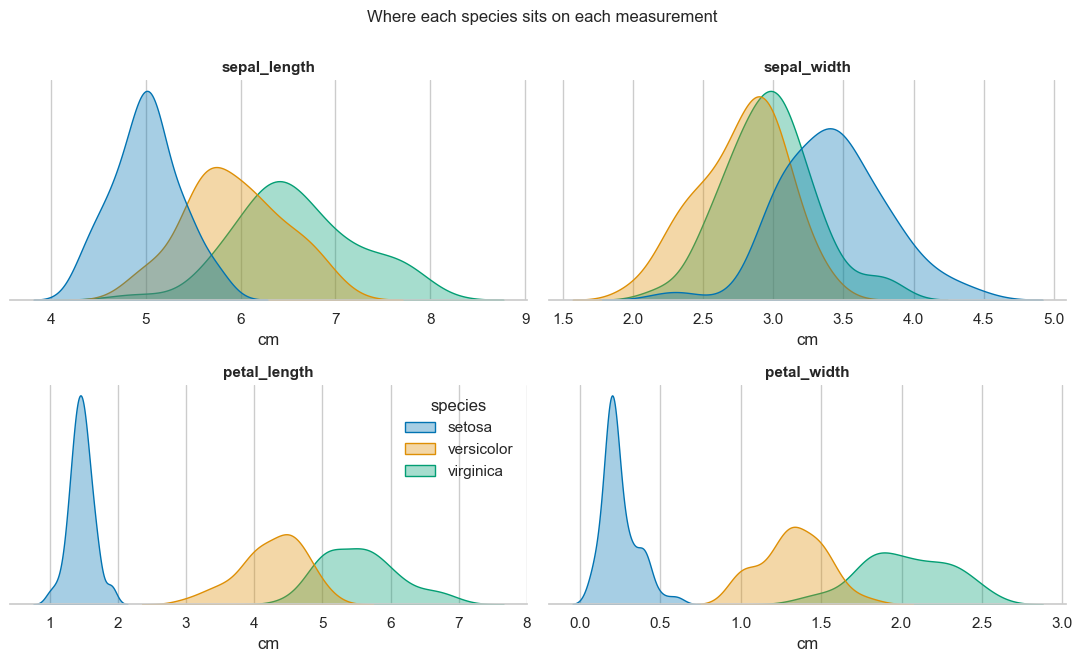

In [11]:
features = FEATURES

fig, axes = plt.subplots(2, 2, figsize=(11, 6.6))
for ax, feat in zip(axes.flat, features):
    sns.kdeplot(data=iris, x=feat, hue="species", hue_order=SPECIES_ORDER,
                palette=SPECIES_COLORS, fill=True, alpha=.35,
                common_norm=False, legend=(feat == "petal_length"), ax=ax)
    ax.set_title(feat, fontsize=11, weight="bold")
    ax.set_xlabel("cm"); ax.set_ylabel("")
    ax.set_yticks([])
    if feat == "petal_length":                 # park it in the empty top-right
        sns.move_legend(ax, "upper right", frameon=False, title="species")
sns.despine(left=True)
fig.suptitle("Where each species sits on each measurement", fontsize=12, y=1.0)
plt.tight_layout(); plt.show()

**Reading the result** — now the story is obvious.

- **Top row (sepal)**: the three curves sit on top of each other. Given only a
  sepal measurement, you often cannot tell the species.
- **Bottom row (petal)**: blue setosa is a completely separate hill, with **empty
  space** between it and the other two. Orange and green overlap a little at their
  edges, but their peaks are clearly apart.

That empty gap in the petal charts is the whole reason iris works as a teaching
dataset. It is a classification problem you can literally see.

## 11. One chart that shows everything — `pairplot`

> 💡 **Engineering Extension** — *Recommended Extension - Not part of instructor curriculum*

`sns.pairplot` plots every feature against every other feature in one grid. For a
small dataset it is usually the very first thing to run.

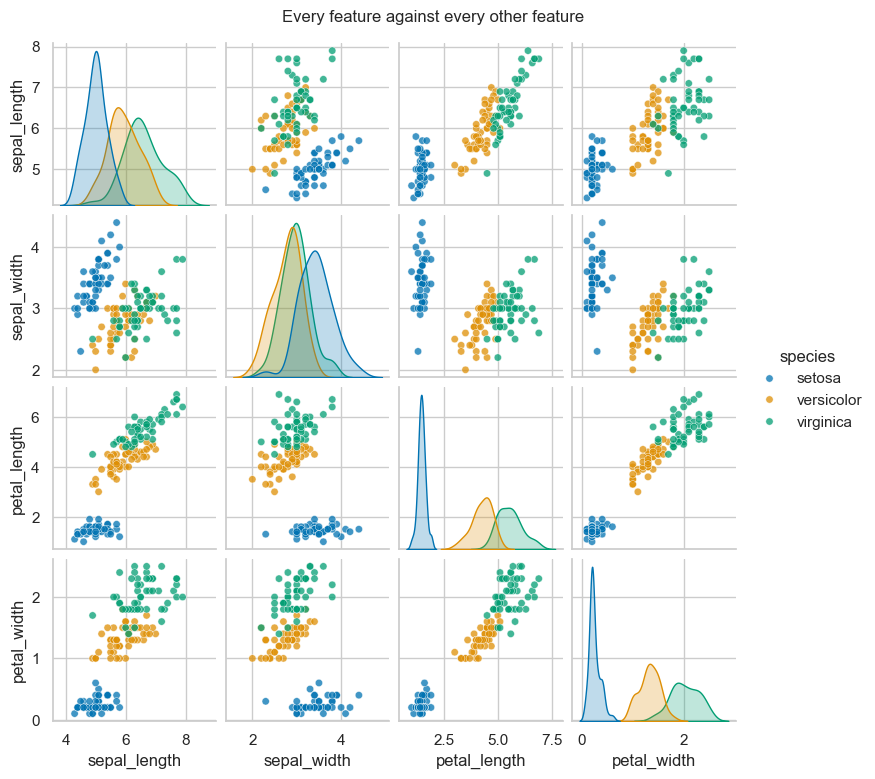

In [12]:
g = sns.pairplot(iris, hue="species", hue_order=SPECIES_ORDER,
                 palette=SPECIES_COLORS, diag_kind="kde",
                 plot_kws=dict(s=28, alpha=.75, edgecolor="white", linewidth=.4),
                 height=1.9)
g.figure.suptitle("Every feature against every other feature", y=1.02, fontsize=12)
plt.show()

**How to read a pairplot**

- The **diagonal** is each feature on its own — the same distribution curves as above.
- Each **off-diagonal** cell is a scatter of one feature against another.
- The grid is mirrored across the diagonal, so you only need to read one half.

**What to look for:** find the cell where the coloured clouds separate most cleanly.
Here it is `petal_length` against `petal_width` — blue setosa sits alone in the
bottom-left corner with clear space around it, and orange and green form two
mostly-separate clusters that touch only at the boundary.

Compare that with the `sepal_length` / `sepal_width` cell, where all three colours
are mixed into one blob. Same flowers, different columns, completely different
usefulness.

## 12. How the columns relate to each other

A correlation says how strongly two columns move together. `+1.0` means they rise
together perfectly, `0.0` means no relationship, `-1.0` means one rises as the
other falls.

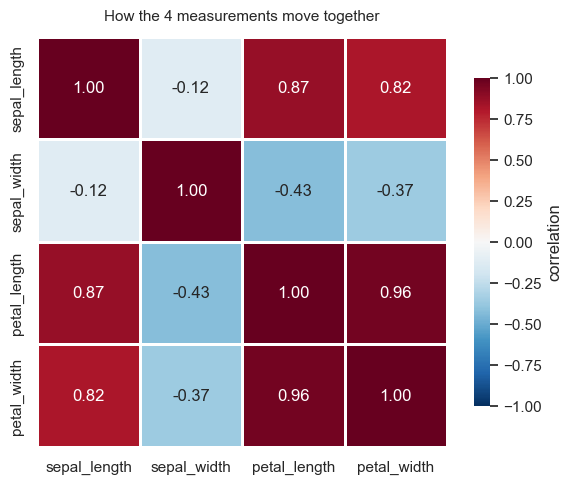

In [13]:
corr = iris[features].corr()

fig, ax = plt.subplots(figsize=(6.2, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, square=True, linewidths=2, linecolor="white",
            cbar_kws=dict(label="correlation", shrink=.8), ax=ax)
ax.set_title("How the 4 measurements move together", fontsize=11, pad=12)
plt.tight_layout(); plt.show()

**Reading the result**

- **`petal_length` and `petal_width`: 0.96.** Almost perfectly linked. A long petal
  is a wide petal. These two columns carry nearly the same information.
- **`sepal_length` with either petal column: 0.87 / 0.82.** Strong. Bigger flowers
  are bigger all over.
- **`sepal_width` with everything: -0.12 to -0.43.** Weak and negative. This column
  behaves differently from the other three.

**Why an engineer cares.** Two columns at 0.96 are largely redundant. Feeding both
into a linear model causes *multicollinearity* — the model cannot tell which of the
two deserves the credit, so the individual coefficients become unstable and hard to
interpret. The predictions are usually still fine; the explanation is not. This is
the motivation for dimensionality reduction such as PCA, which you will meet later.

## 13. So how separable is it really?

The charts suggest that petal size alone almost solves the problem. Let us check
that with the crudest possible model: two `if` statements, no machine learning.

In [14]:
# A hand-written decision tree, straight off the petal charts.
prediction = np.where(iris.petal_length < 2.5, "setosa",
             np.where(iris.petal_width  < 1.75, "versicolor", "virginica"))

print("2-rule accuracy      :", f"{(prediction == iris.species).mean():.1%}")
print("setosa rule alone    :", f"{((iris.petal_length < 2.5) == (iris.species == 'setosa')).mean():.1%}")
print()
print(pd.crosstab(iris.species, prediction,
                  rownames=["actual"], colnames=["predicted"]).to_string())

2-rule accuracy      : 96.0%
setosa rule alone    : 100.0%

predicted   setosa  versicolor  virginica
actual                                   
setosa          50           0          0
versicolor       0          49          1
virginica        0           5         45


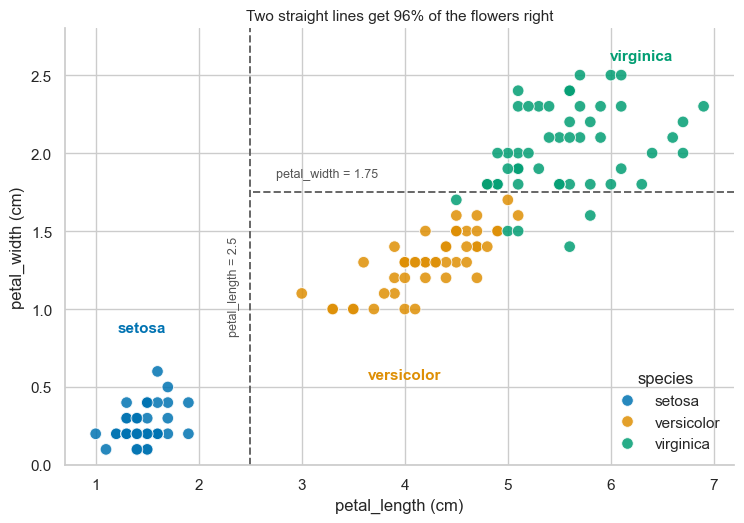

In [15]:
fig, ax = plt.subplots(figsize=(7.6, 5.4))
sns.scatterplot(data=iris, x="petal_length", y="petal_width",
                hue="species", hue_order=SPECIES_ORDER, palette=SPECIES_COLORS,
                s=70, alpha=.85, edgecolor="white", linewidth=.7, ax=ax)
ax.axvline(2.5,  color="#666", ls="--", lw=1.4)
ax.axhline(1.75, color="#666", ls="--", lw=1.4, xmin=.28)
ax.text(2.40, 1.15, "petal_length = 2.5", rotation=90, ha="right", va="center",
        fontsize=9, color="#555")
ax.text(2.75, 1.83, "petal_width = 1.75", ha="left", va="bottom",
        fontsize=9, color="#555")
for label, x, y, colour in [("setosa", 1.45, .85, SPECIES_COLORS["setosa"]),
                            ("versicolor", 4.0, .55, SPECIES_COLORS["versicolor"]),
                            ("virginica", 6.3, 2.60, SPECIES_COLORS["virginica"])]:
    ax.text(x, y, label, color=colour, fontsize=11, weight="bold", ha="center")
ax.set_ylim(0, 2.8)
ax.set_xlabel("petal_length (cm)"); ax.set_ylabel("petal_width (cm)")
ax.set_title("Two straight lines get 96% of the flowers right", fontsize=11)
ax.legend(title="species", frameon=False, loc="lower right")
sns.despine(); plt.tight_layout(); plt.show()

**Reading the result**

- **Setosa is 100% separated** by a single rule: `petal_length < 2.5`. Not one
  mistake in 50 flowers. In ML terms setosa is *linearly separable* from the rest.
- **The 2-rule model scores 96%** — 6 wrong out of 150. Every mistake is a
  versicolor / virginica mix-up, in the band where the orange and green clouds
  touch.
- No training. No library. Two numbers read off a chart.

This is the honest lesson of iris: a good chart found the answer before any model
did, and a real classifier will only recover the last few percent. **Always plot
the data before reaching for an algorithm.**

## 14. Common mistakes

1. **Thinking sepal columns are as useful as petal columns.** They are not. Two of
   the four features do most of the work.
2. **Judging a model by iris.** 95%+ is the floor here, not an achievement. A
   result on iris tells you your code runs, not that your model is good.
3. **Using `species` as a plot axis.** It is text. It belongs in `hue`, or on a
   categorical axis in a `countplot` / `boxplot`.
4. **Letting the colours change between charts.** If setosa is blue in one chart and
   orange in the next, the reader has to re-learn the legend every time. Fix the
   palette once — as this notebook does with `SPECIES_COLORS`.
5. **Forgetting the versicolor / virginica overlap.** People remember "iris is easy"
   and forget that two of the three species genuinely touch. That overlap is where
   all the interesting model differences show up.

## 15. Key takeaway

> **If you remember only one thing...** iris is 150 flowers × 4 measurements ×
> 3 species, and **the petal columns are the ones that matter**. `petal_length` and
> `petal_width` separate the species almost perfectly — two straight lines get 96%
> right — while the sepal columns overlap and mostly do not help.

**Cheat sheet for your later work:**

| You want | Use |
|---|---|
| Load it | `iris = sns.load_dataset("iris")` |
| Features (`X`) | `iris[["sepal_length","sepal_width","petal_length","petal_width"]]` |
| Label (`y`) | `iris["species"]` |
| Best 2 columns for a clean chart | `petal_length`, `petal_width` |
| Worst single column | `sepal_width` |
| Colour by species | `hue="species"` |
| See everything at once | `sns.pairplot(iris, hue="species")` |

**Next:** go back to [`test.ipynb`](./test.ipynb) and re-read your plots. You now
know why the `petal_length` scatter separates so cleanly, and why a `lineplot` on
this data is the wrong chart type — iris has no time or sequence axis, so the
connecting line joins unrelated flowers.